In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report
import seaborn as sn

In [2]:
df = sn.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X= df.drop('species' , axis = 1)
y = df['species']

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [5]:
# We don't need to do train_test_split when we have to do  cross Validation  
# -> But in Ensemble Learning we have to do Train_Test_split before cv

X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [6]:
# 1. Base model 

base_model = [
      ('DT' , DecisionTreeClassifier(random_state=42)), 
      ('LR' , LogisticRegression(max_iter=1000)), 
      ('SVM', SVC(probability=True , kernel='rbf' , random_state= 42)),
]


In [7]:
# Meta model 

meta_model = LogisticRegression(max_iter=1000)

In [8]:
stacking_clf = StackingClassifier(
    estimators = base_model, 
    final_estimator = meta_model, 
    cv = 5
)

In [9]:
stacking_clf.fit(X_train , y_train)

,estimators,"[('DT', ...), ('LR', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [10]:
y_pred = stacking_clf.predict(X_test)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9666666666666667


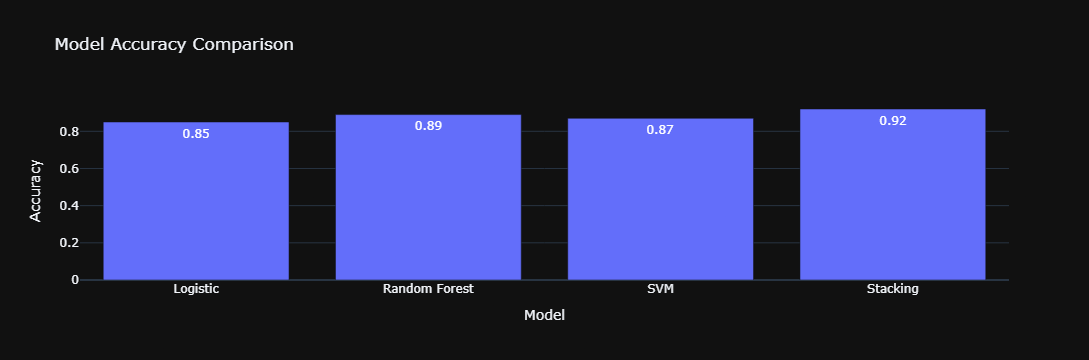

In [3]:
import plotly.express as px
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic', 'Random Forest', 'SVM', 'Stacking'],
    'Accuracy': [0.85, 0.89, 0.87, 0.92]
})

fig = px.bar(
    results,
    x='Model',
    y='Accuracy',
    text='Accuracy',
    title='Model Accuracy Comparison'
)
fig.update_layout(template = 'plotly_dark')
fig.show()

# Random Forest Tree

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
RF_model = RandomForestClassifier(
    n_estimators = 100 , # Number of Tree 
    max_depth = None ,   # Let trees grow fully 
    random_state = 42
)

In [14]:
RF_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_rf = RF_model.predict(X_test)
print(y_pred_rf)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [19]:
accuracy = accuracy_score(y_test , y_pred_rf)
accuracy

0.9